In [1]:
import pandas as pd

In [ ]:
enzexp_data = pd.read_csv("../data/EnzymeExplorer_Dataset.csv")
positives = enzexp_data[enzexp_data["Type"] != "Unknown"]
negatives = enzexp_data[enzexp_data["Type"] == "Unknown"]

In [6]:
! mkdir -p leakage_check/positives
! mkdir -p leakage_check/negatives
! mkdir -p leakage_check/negs_vs_pos

In [5]:
for i in range(5):
    with open(f"leakage_check/positives/pos_test_{i}.fasta", "w") as f:
        for index, row in positives[(positives.Fold == i)].drop_duplicates("ID").iterrows():
            f.write(f">{row['ID']}\n{row['Aminoacid_sequence']}\n")

    with open(f"leakage_check/positives/pos_train_{i}.fasta", "w") as f:
        for index, row in positives[(positives.Fold != i)].drop_duplicates("ID").iterrows():
            f.write(f">{row['ID']}\n{row['Aminoacid_sequence']}\n")
            
    with open(f"leakage_check/negatives/neg_test_{i}.fasta", "w") as f:
        for index, row in negatives[(negatives.Fold == i)].drop_duplicates("ID").iterrows():
            f.write(f">{row['ID']}\n{row['Aminoacid_sequence']}\n")
            
    with open(f"leakage_check/negatives/neg_train_{i}.fasta", "w") as f:
        for index, row in negatives[(negatives.Fold != i)].drop_duplicates("ID").iterrows():
            f.write(f">{row['ID']}\n{row['Aminoacid_sequence']}\n")

In [7]:
! mmseqs easy-search leakage_check/positives/pos_test_0.fasta leakage_check/positives/pos_train_0.fasta leakage_check/positives/alnRes_0.m8 tmp
! mmseqs easy-search leakage_check/positives/pos_test_1.fasta leakage_check/positives/pos_train_1.fasta leakage_check/positives/alnRes_1.m8 tmp
! mmseqs easy-search leakage_check/positives/pos_test_2.fasta leakage_check/positives/pos_train_2.fasta leakage_check/positives/alnRes_2.m8 tmp
! mmseqs easy-search leakage_check/positives/pos_test_3.fasta leakage_check/positives/pos_train_3.fasta leakage_check/positives/alnRes_3.m8 tmp
! mmseqs easy-search leakage_check/positives/pos_test_4.fasta leakage_check/positives/pos_train_4.fasta leakage_check/positives/alnRes_4.m8 tmp

! mmseqs easy-search leakage_check/negatives/neg_test_0.fasta leakage_check/negatives/neg_train_0.fasta leakage_check/negatives/alnRes_0.m8 tmp
! mmseqs easy-search leakage_check/negatives/neg_test_1.fasta leakage_check/negatives/neg_train_1.fasta leakage_check/negatives/alnRes_1.m8 tmp
! mmseqs easy-search leakage_check/negatives/neg_test_2.fasta leakage_check/negatives/neg_train_2.fasta leakage_check/negatives/alnRes_2.m8 tmp
! mmseqs easy-search leakage_check/negatives/neg_test_3.fasta leakage_check/negatives/neg_train_3.fasta leakage_check/negatives/alnRes_3.m8 tmp
! mmseqs easy-search leakage_check/negatives/neg_test_4.fasta leakage_check/negatives/neg_train_4.fasta leakage_check/negatives/alnRes_4.m8 tmp

! mmseqs easy-search leakage_check/positives/pos_test_0.fasta leakage_check/negatives/neg_train_0.fasta leakage_check/negs_vs_pos/pos_2_neg_0.m8 tmp
! mmseqs easy-search leakage_check/positives/pos_test_1.fasta leakage_check/negatives/neg_train_1.fasta leakage_check/negs_vs_pos/pos_2_neg_1.m8 tmp
! mmseqs easy-search leakage_check/positives/pos_test_2.fasta leakage_check/negatives/neg_train_2.fasta leakage_check/negs_vs_pos/pos_2_neg_2.m8 tmp
! mmseqs easy-search leakage_check/positives/pos_test_3.fasta leakage_check/negatives/neg_train_3.fasta leakage_check/negs_vs_pos/pos_2_neg_3.m8 tmp
! mmseqs easy-search leakage_check/positives/pos_test_4.fasta leakage_check/negatives/neg_train_4.fasta leakage_check/negs_vs_pos/pos_2_neg_4.m8 tmp

! mmseqs easy-search leakage_check/negatives/neg_test_0.fasta leakage_check/positives/pos_train_0.fasta leakage_check/negs_vs_pos/neg_2_pos_0.m8 tmp
! mmseqs easy-search leakage_check/negatives/neg_test_1.fasta leakage_check/positives/pos_train_1.fasta leakage_check/negs_vs_pos/neg_2_pos_1.m8 tmp
! mmseqs easy-search leakage_check/negatives/neg_test_2.fasta leakage_check/positives/pos_train_2.fasta leakage_check/negs_vs_pos/neg_2_pos_2.m8 tmp
! mmseqs easy-search leakage_check/negatives/neg_test_3.fasta leakage_check/positives/pos_train_3.fasta leakage_check/negs_vs_pos/neg_2_pos_3.m8 tmp
! mmseqs easy-search leakage_check/negatives/neg_test_4.fasta leakage_check/positives/pos_train_4.fasta leakage_check/negs_vs_pos/neg_2_pos_4.m8 tmp

easy-search leakage_check/positives/pos_test_0.fasta leakage_check/positives/pos_train_0.fasta leakage_check/positives/alnRes_0.m8 tmp 

MMseqs Version:                        	16.747c6
Substitution matrix                    	aa:blosum62.out,nucl:nucleotide.out
Add backtrace                          	false
Alignment mode                         	3
Alignment mode                         	0
Allow wrapped scoring                  	false
E-value threshold                      	0.001
Seq. id. threshold                     	0
Min alignment length                   	0
Seq. id. mode                          	0
Alternative alignments                 	0
Coverage threshold                     	0
Coverage mode                          	0
Max sequence length                    	65535
Compositional bias                     	1
Compositional bias                     	1
Max reject                             	2147483647
Max accept                             	2147483647
Include identical seq. id.      

Text(0.5, 1.0, 'Seq. Id. of TPSs across folds')

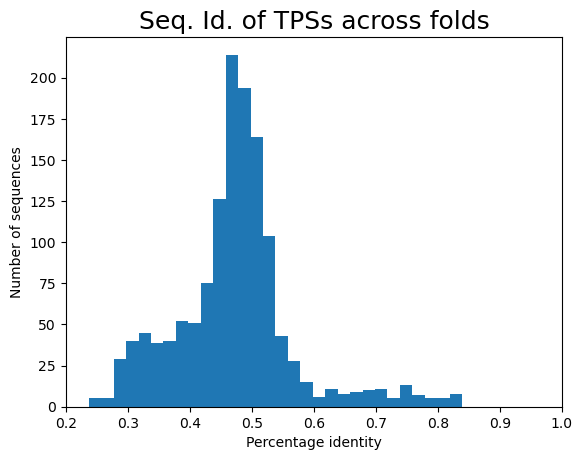

In [8]:
import matplotlib.pyplot as plt
pos_alnResults = [pd.read_csv(f"./leakage_check/positives/alnRes_{i}.m8", sep="\t", names=["id", "subject_id", "perc_identity", "alignment_length", "mismatches", "gap_opens", "q_start", "q_end", "s_start", "s_end", "evalue", "bit_score"]) for i in range(5)]

pos_aln_all = pd.concat(pos_alnResults)
pos_aln_all.sort_values(by=["id", "perc_identity", "bit_score"], ascending=[True, False, False], inplace=True)
pos_aln_all.drop_duplicates("id", keep="first", inplace=True)
pos_aln_all.reset_index(drop=True, inplace=True)
pos_aln_all.sort_values(by="perc_identity", ascending=False, inplace=True)
pos_aln_all.perc_identity.plot(kind='hist', bins=30, title="Seq. Id. of TPSs across folds", xlabel="Percentage identity", ylabel="Number of sequences")
plt.xlim(0.2, 1)
plt.title("Seq. Id. of TPSs across folds", fontsize=18)

Text(0.5, 1.0, 'Seq. Id. of Negatives across folds')

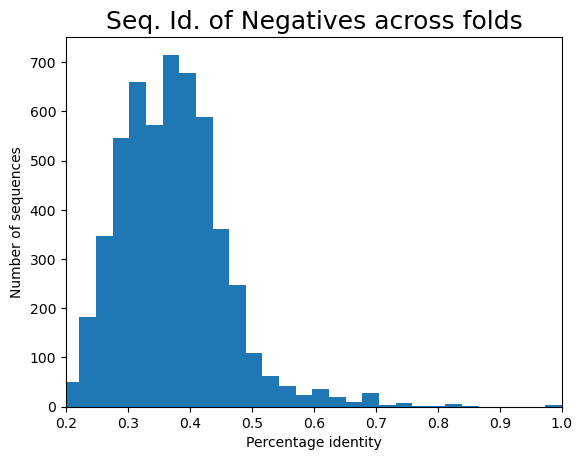

In [9]:
import matplotlib.pyplot as plt
neg_alnResults = [pd.read_csv(f"./leakage_check/negatives/alnRes_{i}.m8", sep="\t", names=["id", "subject_id", "perc_identity", "alignment_length", "mismatches", "gap_opens", "q_start", "q_end", "s_start", "s_end", "evalue", "bit_score"]) for i in range(5)]

neg_aln_all = pd.concat(neg_alnResults)
neg_aln_all.sort_values(by=["id", "perc_identity", "bit_score"], ascending=[True, False, False], inplace=True)
neg_aln_all.drop_duplicates("id", keep="first", inplace=True)
neg_aln_all.reset_index(drop=True, inplace=True)
neg_aln_all.sort_values(by="perc_identity", ascending=False, inplace=True)
neg_aln_all.perc_identity.plot(kind='hist', bins=30, title="Seq. Id. of Negatives across folds", xlabel="Percentage identity", ylabel="Number of sequences")
plt.xlim(0.2, 1)
plt.title("Seq. Id. of Negatives across folds", fontsize=18)

Text(0.5, 1.0, 'Seq. Id. of Negatives to Positives across folds')

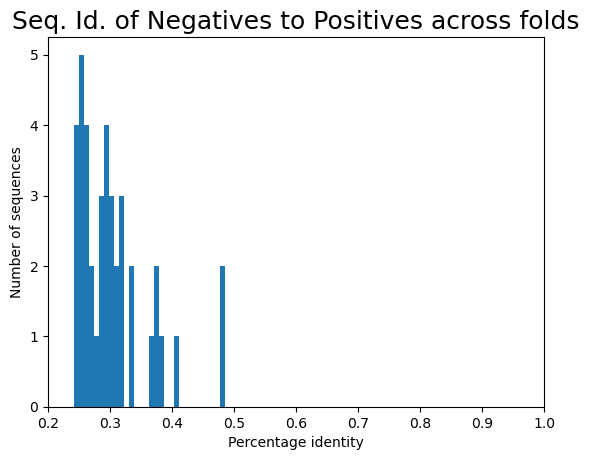

In [11]:
import matplotlib.pyplot as plt
neg_2_pos_alnResults = [pd.read_csv(f"./leakage_check/negs_vs_pos/neg_2_pos_{i}.m8", sep="\t", names=["id", "subject_id", "perc_identity", "alignment_length", "mismatches", "gap_opens", "q_start", "q_end", "s_start", "s_end", "evalue", "bit_score"]) for i in range(5)]

neg_2_pos_aln_all = pd.concat(neg_2_pos_alnResults)
neg_2_pos_aln_all.sort_values(by=["id", "perc_identity", "bit_score"], ascending=[True, False, False], inplace=True)
neg_2_pos_aln_all.drop_duplicates("id", keep="first", inplace=True)
neg_2_pos_aln_all.reset_index(drop=True, inplace=True)
neg_2_pos_aln_all.sort_values(by="perc_identity", ascending=False, inplace=True)
neg_2_pos_aln_all.perc_identity.plot(kind='hist', bins=30, title="Seq. Id. of Negatives to Positives across folds", xlabel="Percentage identity", ylabel="Number of sequences")
plt.xlim(0.2, 1)
plt.title("Seq. Id. of Negatives to Positives across folds", fontsize=18)

Text(0.5, 1.0, 'Seq. Id. of Positives to Negatives across folds')

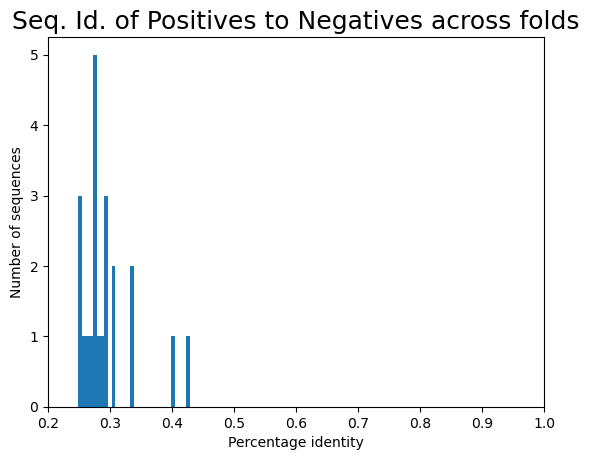

In [12]:
import matplotlib.pyplot as plt
pos_2_neg_alnResults = [pd.read_csv(f"./leakage_check/negs_vs_pos/pos_2_neg_{i}.m8", sep="\t", names=["id", "subject_id", "perc_identity", "alignment_length", "mismatches", "gap_opens", "q_start", "q_end", "s_start", "s_end", "evalue", "bit_score"]) for i in range(5)]

pos_2_neg_aln_all = pd.concat(pos_2_neg_alnResults)
pos_2_neg_aln_all.sort_values(by=["id", "perc_identity", "bit_score"], ascending=[True, False, False], inplace=True)
pos_2_neg_aln_all.drop_duplicates("id", keep="first", inplace=True)
pos_2_neg_aln_all.reset_index(drop=True, inplace=True)
pos_2_neg_aln_all.sort_values(by="perc_identity", ascending=False, inplace=True)
pos_2_neg_aln_all.perc_identity.plot(kind='hist', bins=30, title="Seq. Id. of Positives to Negatives across folds", xlabel="Percentage identity", ylabel="Number of sequences")
plt.xlim(0.2, 1)
plt.title("Seq. Id. of Positives to Negatives across folds", fontsize=18)